# NETBCI：十个发布身份的纵向分析与来源重复敏感性

2026-10-10 接续分析的可重运行伴随 notebook。仅读取保存且有 SHA-256
收据的队列表格；不下载数据、读取原始张量、重新训练模型或修改科研参数。
图使用下面的可编辑 Matplotlib 代码，输出保存在 notebook 中。

## tl;dr

下方摘要由已保存的实际队列结果计算。全部 240-run 数值检查确认
sub-1/sub-7 跨身份复制，因此原十身份 EEG 区间只作算术记录。
另存八身份来源敏感性；在线命中成绩、离线 Balanced Accuracy 和 EEG 几何分别解释。

In [1]:
from pathlib import Path
import hashlib
import importlib.metadata
import io
import json
import platform

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = next((path for path in [Path.cwd(), *Path.cwd().parents]
             if (path / "configs/netbci_cohort_full_windows_20261010.json").is_file()), None)
assert ROOT is not None, "Run from the repository or its notebooks directory."

In [2]:
RESULTS = ROOT / 'research_logs/netbci_cohort_resume_20261010/summary_run01'
CONFIG = ROOT / "configs/netbci_cohort_full_windows_20261010.json"
ORIGINAL_CONFIG = ROOT / "configs/netbci_cohort.json"

def sha256(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()

assert (RESULTS / "summary_receipt.json").is_file(), "Complete the cohort summary first."
receipt = json.loads((RESULTS / "summary_receipt.json").read_text())
summary = json.loads((RESULTS / "cohort_summary.json").read_text())
config = json.loads(CONFIG.read_text())
original = json.loads(ORIGINAL_CONFIG.read_text())
assert receipt["synthetic"] is False and summary["synthetic"] is False
assert receipt["status"] == "actual_data_summary_completed"
assert sha256(CONFIG) == receipt["config_sha256"]
policy_fields = {"output_root", "bundle_root", "fixed_window_duration_seconds", "mismatch_action",
                 "status", "eligibility_policy_timing"}
assert {k: v for k, v in config.items() if k not in policy_fields} == {
    k: v for k, v in original.items() if k not in policy_fields}
assert config["fixed_window_duration_seconds"] == 5.0
assert config["mismatch_action"] == "retain_source_event_exclude_from_fixed_window_tensor"
assert config["status"] == "exploratory_cohort_with_post_observation_full_window_eligibility"
assert "after strict sub-3 source-duration failure" in config["eligibility_policy_timing"]

TABLE_NAMES = ["participant_session_join.tsv", "cohort_session_statistics.tsv",
               "participant_first_last_changes.tsv", "cohort_paired_changes.tsv",
               "spectral_reference_QC_sensitivity.tsv", "participant_matched_geometry.tsv",
               "cohort_matched_statistics.tsv"]
source_rows = []
for name in [*TABLE_NAMES, "cohort_summary.json"]:
    assert sha256(RESULTS / name) == receipt["output_sha256"][name], name
    source_rows.append({"Artifact": name, "SHA-256": sha256(RESULTS / name)})

def load_table(name):
    return pd.read_csv(RESULTS / name, sep="\t", dtype={
        "subject": str, "session": str, "metric": str, "variant": str},
        keep_default_na=True)

linked, session_stats, individual_changes, paired, spectral, geometry, matched_stats = [
    load_table(name) for name in TABLE_NAMES]
SUBJECTS, SESSIONS = config["subjects"], config["session_order"]
assert SUBJECTS == [f"sub-{i}" for i in range(1, 11)]
assert summary["participants"] == 10 and len(linked) == 40
assert not linked.duplicated(["subject", "session"]).any()
assert set(zip(linked.subject, linked.session)) == {
    (subject, session) for subject in SUBJECTS for session in SESSIONS}
assert int(linked.n_EEG_trials.sum()) == summary["trials"]
assert int(linked.n_EEG_source_events.sum()) == summary["source_events"]
assert int(linked.n_EEG_excluded_events.sum()) == summary["excluded_source_events_n"]
assert summary["source_events"] == summary["trials"] + summary["excluded_source_events_n"]
assert (linked.n_EEG_source_events == linked.n_EEG_trials + linked.n_EEG_excluded_events).all()
assert (linked.n_source_rest + linked.n_source_MI == linked.n_EEG_source_events).all()
assert (linked.n_rest + linked.n_MI == linked.n_EEG_trials).all()
assert int(linked.n_EEG_runs.sum()) == summary["runs"]
assert not geometry.duplicated(["subject", "session", "variant"]).any()
assert set(zip(geometry.subject, geometry.session, geometry.variant)) == {
    (subject, session, variant) for subject in SUBJECTS for session in SESSIONS
    for variant in ["all_six_runs", "qc_common_four_runs"]}
assert geometry.status.isin(["available", "unavailable"]).all()
assert (geometry.groupby(["subject", "variant"]).status.nunique() == 1).all()
assert not individual_changes.duplicated(["subject", "metric"]).any()
assert (paired.n_requested_subjects == 10).all()
assert receipt["bootstrap_unit"] == "whole participant"

IDENTITY = RESULTS.parent / "numeric_signal_identity.json"
SENSITIVITY = RESULTS.parent / "independence_sensitivity_run01"
sensitivity_receipt = json.loads((SENSITIVITY / "sensitivity_receipt.json").read_text())
assert sensitivity_receipt["status"] == "completed_real_data_sensitivity"
assert sensitivity_receipt["synthetic"] is False
assert sha256(IDENTITY) == sensitivity_receipt["input_sha256"]["identity_audit"]["sha256"]
assert sha256(RESULTS / "summary_receipt.json") == sensitivity_receipt["input_sha256"]["summary_receipt"]["sha256"]
for name, expected_hash in sensitivity_receipt["output_sha256"].items():
    assert sha256(SENSITIVITY / name) == expected_hash, name
    source_rows.append({"Artifact": "independence_sensitivity_run01/" + name, "SHA-256": expected_hash})
source_rows.extend([{"Artifact": "numeric_signal_identity.json", "SHA-256": sha256(IDENTITY)},
                    {"Artifact": "independence_sensitivity_run01/sensitivity_receipt.json",
                     "SHA-256": sha256(SENSITIVITY / "sensitivity_receipt.json")}])
identity = json.loads(IDENTITY.read_text())
sensitivity = json.loads((SENSITIVITY / "sensitivity_summary.json").read_text())
assert identity["status"] == "complete_exact_numeric_identity_audit"
assert identity["summary"]["continuous_runs"] == 240
assert identity["summary"]["continuous_duplicate_groups"] == 6
assert identity["summary"]["continuous_duplicate_members"] == 24
assert identity["summary"]["task_window_duplicate_groups"] == 178
assert identity["summary"]["task_window_duplicate_members"] == 712
assert identity["production_partition_content_overlap"]["source_training_later_query_affected_trials"] == 238
assert sensitivity["excluded_identities"] == ["sub-1", "sub-7"]
assert sensitivity["retained_identities"] == ["sub-2", "sub-3", "sub-4", "sub-5", "sub-6", "sub-8", "sub-9", "sub-10"]
assert sensitivity["no_model_refitting"] and sensitivity["not_independent_confirmation"]
sensitive_paired = pd.read_csv(SENSITIVITY / "cohort_paired_changes.tsv", sep="\t")
assert (sensitive_paired.n_paired_subjects == 8).all()
assert sensitivity_receipt["original_primary_outputs_modified"] is False
print("Verified inputs:", len(TABLE_NAMES), "tables;", len(linked), "participant/session rows.")

Verified inputs: 7 tables; 40 participant/session rows.


In [3]:
def change_line(metric, label, unit):
    row = paired.loc[paired.metric == metric].iloc[0]
    if pd.isna(row.mean_change):
        return f"- {label}：不可用，配对人数 {int(row.n_paired_subjects)}/10。"
    return (f"- {label}：末次−首次平均 {row.mean_change:+.3f} {unit}；"
            f"发布身份配对 bootstrap 算术区间 [{row.subject_bootstrap_CI95_low:.3f}, "
            f"{row.subject_bootstrap_CI95_high:.3f}]，n={int(row.n_paired_subjects)}/10；"
            f"增加/下降/不变 = {int(row.n_increased)}/{int(row.n_decreased)}/{int(row.n_unchanged)}。")

lines = [f"**实际纳入：10 个发布身份、{summary['sessions']} 个会话、{summary['runs']} 个 runs；"
         f"完整来源清单 {summary['source_events']:,} 个事件，其中 {summary['trials']:,} 个"
         f"符合固定 5 秒张量条件，{summary['excluded_source_events_n']} 个有明确排除记录。**",
         change_line("mean_run_hit_percent", "公开在线成绩", "个百分点"),
         change_line("CSP_BA_percent", "冻结 CSP+LDA Balanced Accuracy", "个百分点"),
         change_line("mu_MI_minus_rest_dB", "Mu 任务窗 MI−rest 对比变化", "dB"),
         f"- 主分析保留 {summary['qc_flags_retained_in_primary']} 个 QC 标记任务窗；"
         f"至少一次恒预测的发布身份：{len(summary['constant_prediction_participants'])}/10。",
         "**完整 240-run 数值检查确认：sub-7 ses-01/02/03 的全部六个对应 run"
         "均与 sub-1 ses-04 相同，共六组四方重复；178 组真实任务窗口重复，712 条记录。"
         "sub-7 ses-02/03 各有 119 个 source training 窗口在 query 重现，共 238 条训练→后续"
         "query 内容重合；另各有 59 个重复 source reference query。官方校验通过仍不保证"
         "采集独立，原始 BrainVision EEG 未在本检查中实读，重复原因未明。"
         "下方 n=10 是发布身份数；原 EEG 区间与关联只作算术记录，不能解释为"
         "十个独立参与者的生物学证据。**",
         "**另存来源审计后的 n=8 敏感性：同时排除 sub-1 与 sub-7，依据数值副本、"
         "不依据结果方向。冻结 BA 变化 −9.502 pp [−20.244, 2.735]；Mu 变化 −0.679 dB"
         " [−1.317, −0.047]。这是观察后的探索性分析，不是独立确认。原十身份表没有覆盖，"
         "没有重新拟合；原始 19 人已发布行为记录的样本量不变。**",
         "这些是编号顺序前 10 人的探索性、观察性结果；不能据此分离人的学习、"
         "历史在线解码器变化或证明技能保持。"]
display(Markdown("\n\n".join(lines)))

**实际纳入：10 个发布身份、40 个会话、240 个 runs；完整来源清单 7,577 个事件，其中 7,576 个符合固定 5 秒张量条件，1 个有明确排除记录。**

- 公开在线成绩：末次−首次平均 +14.268 个百分点；发布身份配对 bootstrap 算术区间 [10.085, 18.291]，n=10/10；增加/下降/不变 = 10/0/0。

- 冻结 CSP+LDA Balanced Accuracy：末次−首次平均 -12.573 个百分点；发布身份配对 bootstrap 算术区间 [-22.954, -1.596]，n=10/10；增加/下降/不变 = 2/8/0。

- Mu 任务窗 MI−rest 对比变化：末次−首次平均 -0.410 dB；发布身份配对 bootstrap 算术区间 [-1.168, 0.492]，n=10/10；增加/下降/不变 = 5/5/0。

- 主分析保留 75 个 QC 标记任务窗；至少一次恒预测的发布身份：5/10。

**完整 240-run 数值检查确认：sub-7 ses-01/02/03 的全部六个对应 run均与 sub-1 ses-04 相同，共六组四方重复；178 组真实任务窗口重复，712 条记录。sub-7 ses-02/03 各有 119 个 source training 窗口在 query 重现，共 238 条训练→后续query 内容重合；另各有 59 个重复 source reference query。官方校验通过仍不保证采集独立，原始 BrainVision EEG 未在本检查中实读，重复原因未明。下方 n=10 是发布身份数；原 EEG 区间与关联只作算术记录，不能解释为十个独立参与者的生物学证据。**

**另存来源审计后的 n=8 敏感性：同时排除 sub-1 与 sub-7，依据数值副本、不依据结果方向。冻结 BA 变化 −9.502 pp [−20.244, 2.735]；Mu 变化 −0.679 dB [−1.317, −0.047]。这是观察后的探索性分析，不是独立确认。原十身份表没有覆盖，没有重新拟合；原始 19 人已发布行为记录的样本量不变。**

这些是编号顺序前 10 人的探索性、观察性结果；不能据此分离人的学习、历史在线解码器变化或证明技能保持。

## Context & Methods

固定来源：NEMAR nm000305 v1.0.0（CC BY 4.0，
DOI [10.82901/nemar.nm000305.v1.0.0](https://doi.org/10.82901/nemar.nm000305.v1.0.0)）；
真实行为来自原始 Dataverse v2.2 的参与者侧表
（DOI [10.57745/RBJRC7](https://doi.org/10.57745/RBJRC7)）。纳入发布编号
sub-1 至 sub-10，无行为/EEG 结果筛选；先导 sub-1 和 19 人行为此前已经观察。

接续审计观察到 sub-3 一个 2.968 秒 rest 事件后，显式新增固定 5 秒窗口
输入条件：短事件保留在完整来源清单和排除表，不能填补、延长或伪造标签。
这是**观察后的探索性输入政策修订**，不是读取数据前未变更的确认性方案。
原频带、分区、模型、QC、匹配、bootstrap 参数均保持原值。

每人 session01 run01–04 拟合 QC、变换和 CSP+LDA；同会话 run05–06
是 ID 互斥的 query，后续三个会话使用六个 runs。完整数值检查另查内容重合，
不能以 ID 互斥代替来源独立。session02 是不调参的 validation
descriptor，session03/04 是探索性 test。模型在 query 前后核验冻结。

### Key Assumptions

- 会话在线成绩是六个已报告百分比的等权平均，**不是 pooled hit rate**。
  subject/session 关联有来源证明；run 顺序、分母、逐 trial outcome 仍未解决。
- Mu/Beta 是平均参考下 C3/Cz/C4、0.5–4.5 秒任务窗、Welch 250/125 的
  MI−rest log-power 对比；没有已验证事件前基线，**不是经典 ERD**。
- 几何采用统一坐标、trace normalization、5% shrinkage 和 PCA10。
  六-run 匹配固定每类/run 12 个 trial（144/session），QC 共同四-run
  固定 96/session、各 10 次抽样，先在每个人内平均。
- 缺失匹配单元保留为不可用，不降 trial 数、不删参与者。QC 标记仅是
  source-only 粗筛，未标记不等于专家审查确认无伪迹。
- 原 95% 区间重采样完整发布身份轨迹 10,000 次、seed42；来源重复使
  EEG 身份独立假设不成立，因此图中区间仅记录算术计算。八身份敏感性未发现
  精确副本，但仍不能保证生物学身份、随机人口样本或人体干预效应。

## Data

下表核对各人真实任务窗数、类别和 QC。来源散列在文末逐项保留，
图中不可用值保持缺失；未用 19 人行为均值替代当前 10 人队列。

In [4]:
inventory = linked.groupby("subject", sort=False).agg(
    Source_events=("n_EEG_source_events", "sum"), Excluded_events=("n_EEG_excluded_events", "sum"),
    Eligible_5s_trials=("n_EEG_trials", "sum"), EEG_runs=("n_EEG_runs", "sum"),
    Eligible_rest=("n_rest", "sum"), Eligible_MI=("n_MI", "sum"),
    QC_flags=("n_qc_flagged", "sum")).reindex(SUBJECTS)
display(inventory)
exclusions = pd.DataFrame(summary["excluded_source_events"])
exclusion_columns = [name for name in ["subject", "session", "run", "label", "duration_seconds",
                                      "duration_s", "duration", "exclusion_reason", "trial_id"]
                     if name in exclusions.columns]
display(exclusions[exclusion_columns])

plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 11,
                     "axes.titlesize": 12, "axes.labelsize": 11,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": False, "figure.facecolor": "white"})
BLUE, GOLD, ORANGE, GRAY = "#245e82", "#a07822", "#b55f2b", "#a4a8ad"
SESSION_X = np.arange(1, len(SESSIONS) + 1)

def matrix(table, field):
    values = table.pivot(index="subject", columns="session", values=field)
    return values.reindex(index=SUBJECTS, columns=SESSIONS).apply(
        pd.to_numeric, errors="coerce").to_numpy(dtype=float)

def decorate_session_axis(ax):
    ax.set_xticks(SESSION_X, SESSIONS)
    ax.set_xlabel("Protocol session (spacing is not elapsed days)")
    ax.grid(axis="y", color="#e5e7e9", linewidth=.65)

def trajectories(ax, values, title, unit, stats=None):
    for series in values:
        ax.plot(SESSION_X, series, "o-", color=GRAY, alpha=.65, lw=1, ms=3)
    n = np.isfinite(values).sum(axis=0)
    means = np.divide(np.nansum(values, axis=0), n,
                      out=np.full(len(SESSIONS), np.nan), where=n > 0)
    ax.plot(SESSION_X, means, "D-", color=BLUE, lw=2.4, ms=5,
            label="Available published-ID mean")
    if stats is not None:
        stats = stats.set_index("session").reindex(SESSIONS)
        ax.fill_between(SESSION_X, stats.subject_bootstrap_CI95_low.to_numpy(float),
                        stats.subject_bootstrap_CI95_high.to_numpy(float),
                        color=BLUE, alpha=.14, label="Published-ID bootstrap interval (arithmetic)")
    ax.set_title(title)
    ax.set_ylabel(unit)
    decorate_session_axis(ax)
    ax.text(.02, .03, "Available n: " + "/".join(map(str, n)),
            transform=ax.transAxes, fontsize=9,
            bbox={"facecolor": "white", "edgecolor": "none", "alpha": .8, "pad": 1})

def show_figure(figure):
    figure.text(.5, -.018,
                "All 240 runs checked: sub-7 sessions 01/02/03 = sub-1 session 04 numerically (six runs each).\n"
                "238 training-to-later-query repeats; ten-ID EEG intervals are arithmetic only. See separate n=8 sensitivity.",
                ha="center", va="top", fontsize=9, color="#7a3b22")
    image = io.BytesIO()
    figure.savefig(image, format="png", dpi=145, bbox_inches="tight", facecolor="white")
    display(Image(data=image.getvalue()))
    plt.close(figure)

,Source_events,Excluded_events,Eligible_5s_trials,EEG_runs,Eligible_rest,Eligible_MI,QC_flags
subject,,,,,,,
sub-1,717,0,717,24,357,360,44
sub-2,767,0,767,24,383,384,0
sub-3,765,1,764,24,381,383,3
sub-4,768,0,768,24,384,384,0
sub-5,765,0,765,24,383,382,7
sub-6,768,0,768,24,384,384,2
sub-7,726,0,726,24,360,366,0
sub-8,766,0,766,24,382,384,19
sub-9,767,0,767,24,384,383,0


,subject,session,run,label,duration_s,exclusion_reason,trial_id
0,sub-3,01,03,rest,2.968,source_event_duration_does_not_match_fixed_window,sub-3/ses-01/run-03/tsv-row-31


## Results

### 1. 在线行为与冻结离线读出的四会话轨迹

灰线保留所有发布身份，蓝线和阴影是身份均值及原 bootstrap 算术区间。
EEG 来源重复使独立参与者解释不成立；图保留计算与异常。
两个端点的单位相同但含义不同，不计算二者的差作为学习增益。
仅离线二分类 BA 有 50% 参考线；不假定光标任务的 chance hit score。

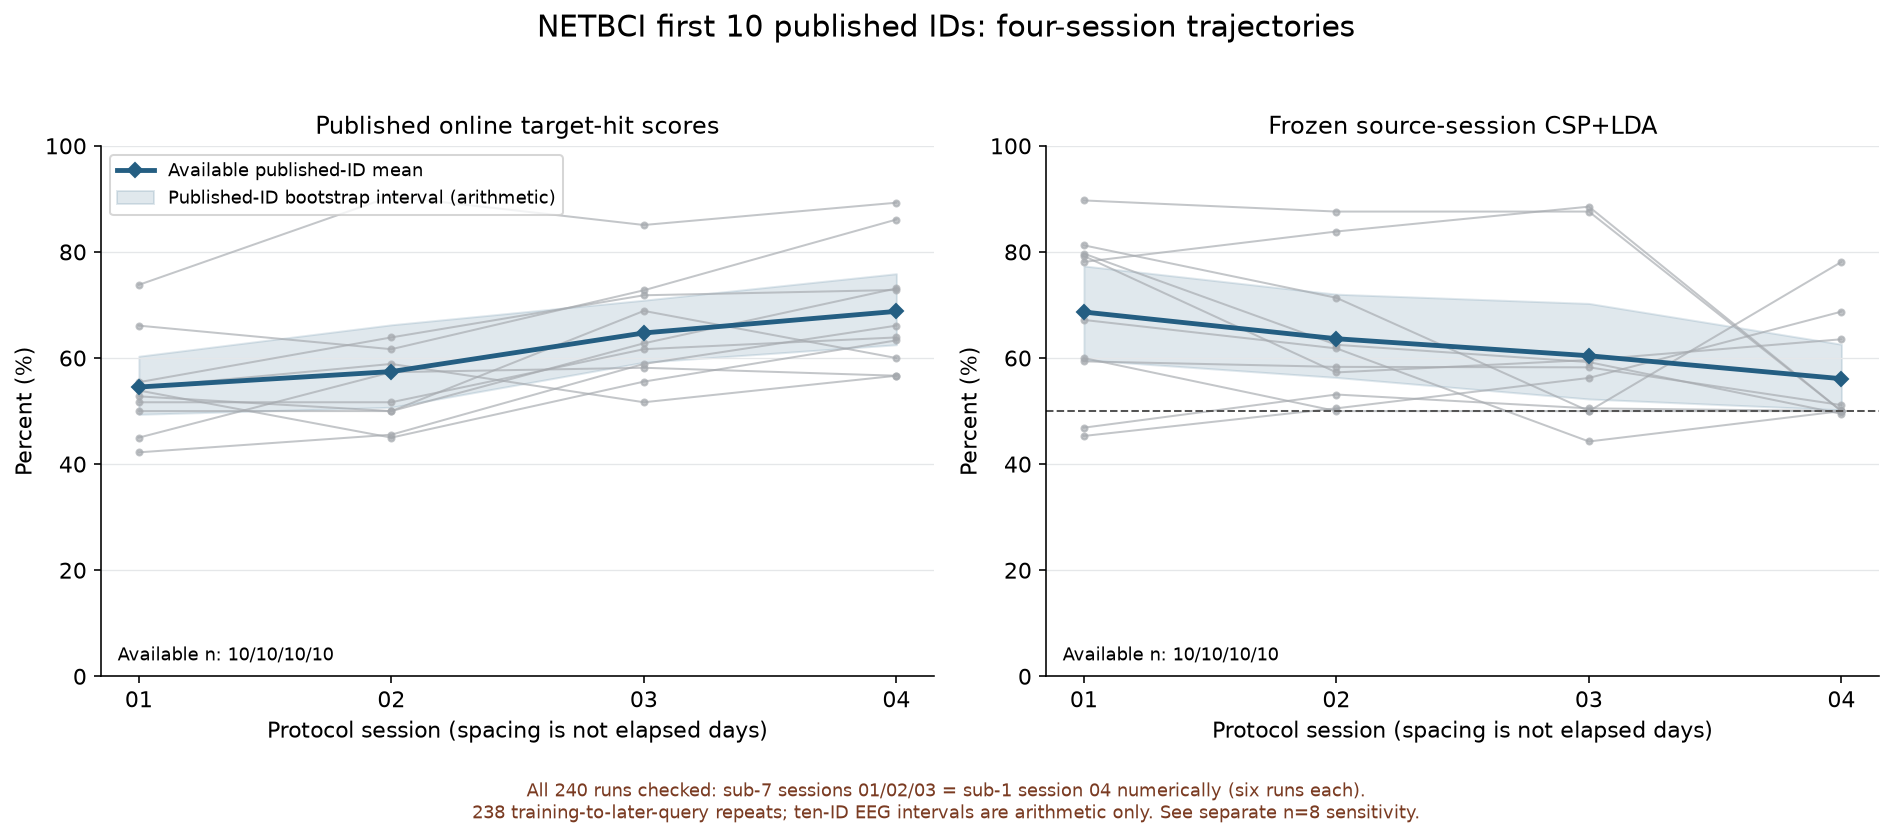

,metric,session,n_available_subjects,mean,subject_bootstrap_CI95_low,subject_bootstrap_CI95_high
0,mean_run_hit_percent,01,10,54.535,49.389,60.342
1,mean_run_hit_percent,02,10,57.448,50.722,66.269
2,mean_run_hit_percent,03,10,64.731,59.206,70.906
3,mean_run_hit_percent,04,10,68.803,62.510,75.901
4,CSP_BA_percent,01,10,68.676,59.656,77.364
5,CSP_BA_percent,02,10,63.642,56.338,72.038
6,CSP_BA_percent,03,10,60.432,52.283,70.296
7,CSP_BA_percent,04,10,56.103,50.236,62.604


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.3))
for ax, metric, title in [
    (axes[0], "mean_run_hit_percent", "Published online target-hit scores"),
    (axes[1], "CSP_BA_percent", "Frozen source-session CSP+LDA")]:
    trajectories(ax, matrix(linked, metric), title, "Percent (%)",
                 session_stats.loc[session_stats.metric == metric])
    ax.set_ylim(0, 100)
axes[1].axhline(50, color="#555555", ls="--", lw=1)
axes[0].legend(loc="upper left", fontsize=9)
fig.suptitle("NETBCI first 10 published IDs: four-session trajectories", fontsize=15)
fig.tight_layout(rect=[0, 0, 1, .95])
show_figure(fig)
display(session_stats.loc[session_stats.metric.isin(["mean_run_hit_percent", "CSP_BA_percent"]),
    ["metric", "session", "n_available_subjects", "mean", "subject_bootstrap_CI95_low",
     "subject_bootstrap_CI95_high"]].round(3))

每人的两条轨迹在下图保持相同 0–100% 尺度与会话顺序；颜色和 marker
区分不同端点，不把它们当作同一任务的可互换成绩。恒预测的会话用空心标记
单独保留，模型不可用时保持缺失。原数据的每人身份未被群体均值掩盖。

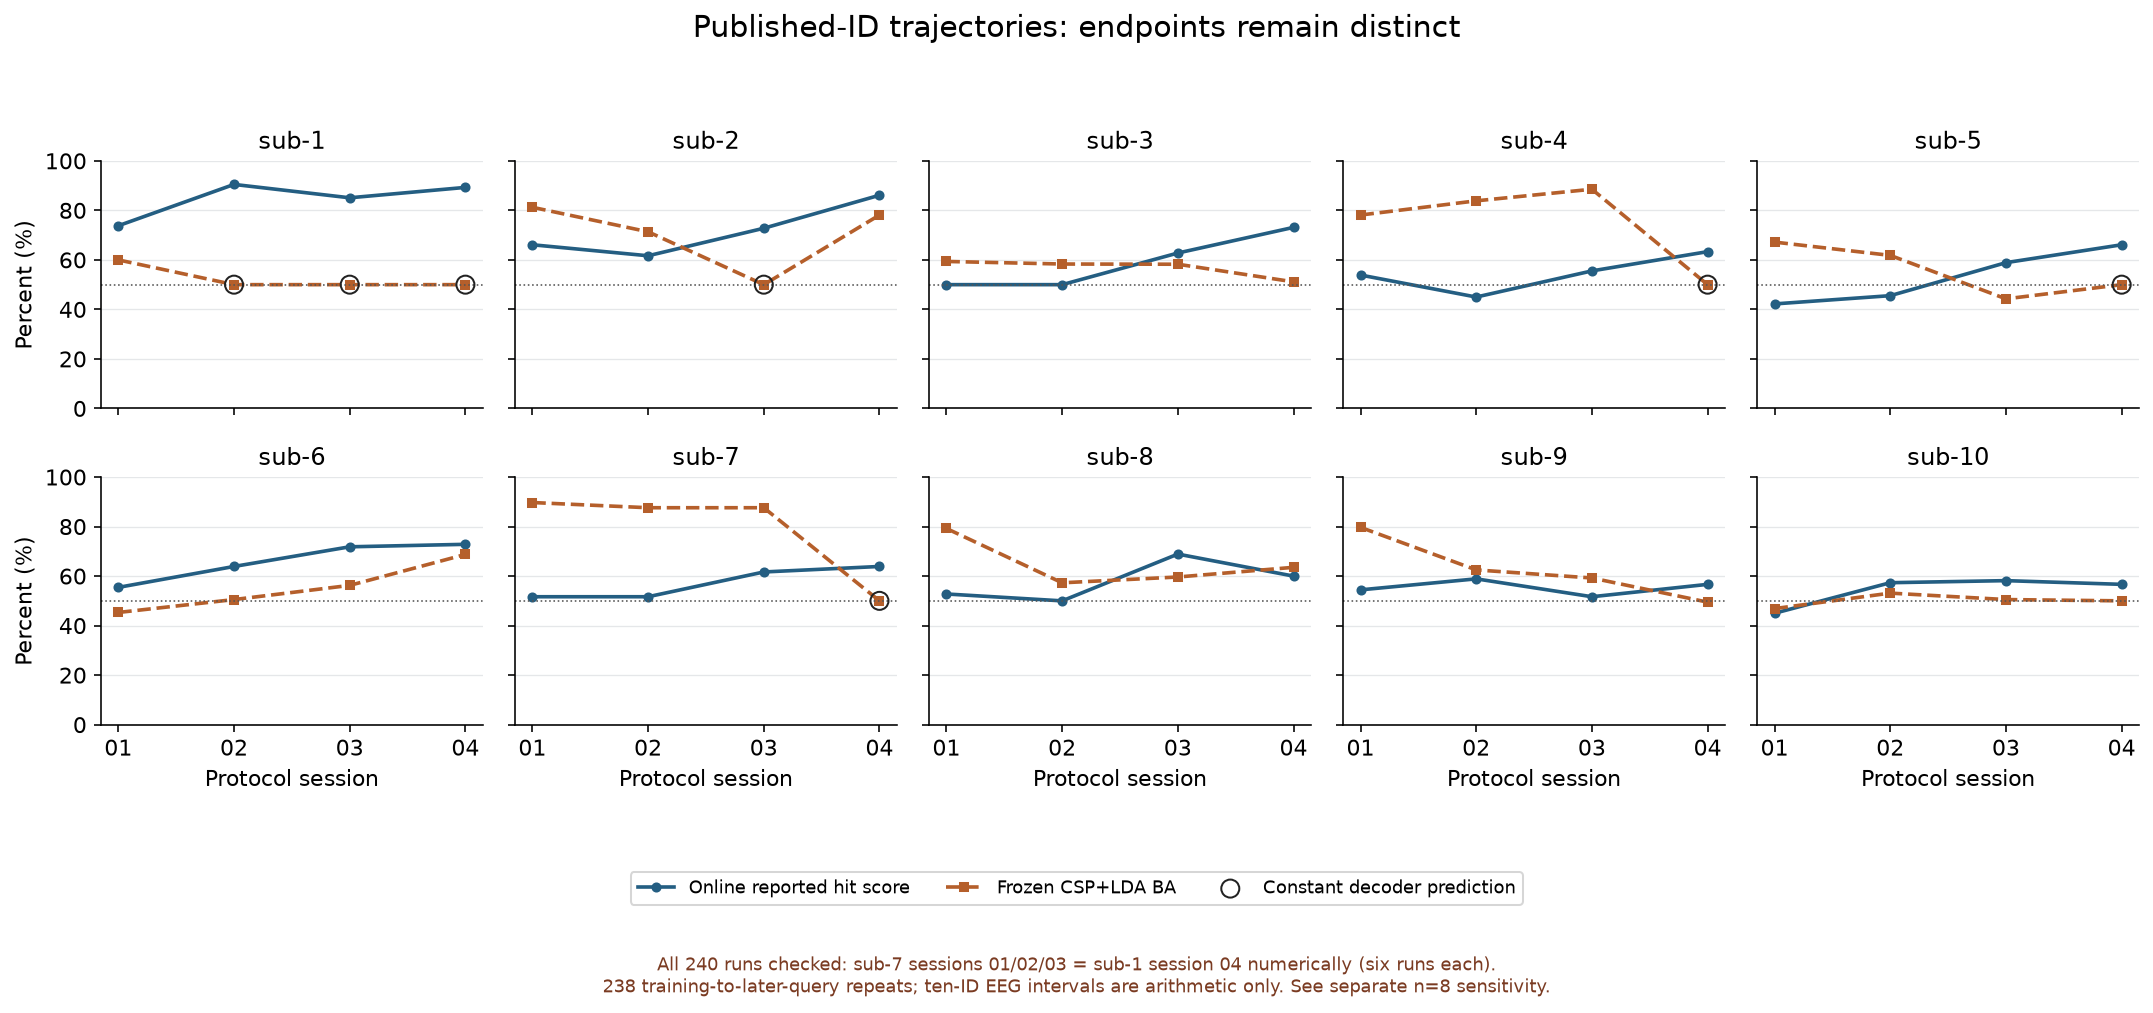

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(15.0, 6.5), sharex=True, sharey=True)
for ax, subject in zip(axes.flat, SUBJECTS):
    rows = linked.loc[linked.subject == subject].set_index("session").reindex(SESSIONS)
    ax.plot(SESSION_X, rows.mean_run_hit_percent, "o-", color=BLUE, lw=1.8, ms=4,
            label="Online reported hit score")
    ax.plot(SESSION_X, rows.CSP_BA_percent, "s--", color=ORANGE, lw=1.8, ms=4,
            label="Frozen CSP+LDA BA")
    constant = rows.CSP_constant_prediction.astype(str).str.lower().eq("true").to_numpy()
    ax.scatter(SESSION_X[constant], rows.CSP_BA_percent.to_numpy()[constant],
               s=80, facecolors="none", edgecolors="#222222", linewidths=1,
               label="Constant decoder prediction", zorder=5)
    ax.axhline(50, color="#555555", ls=":", lw=.8)
    ax.set(title=subject, ylim=(0, 100), xticks=SESSION_X, xticklabels=SESSIONS)
    ax.grid(axis="y", color="#e5e7e9", lw=.65)
for ax in axes[:, 0]:
    ax.set_ylabel("Percent (%)")
for ax in axes[1]:
    ax.set_xlabel("Protocol session")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(.5, .025), ncol=3, fontsize=9)
fig.suptitle("Published-ID trajectories: endpoints remain distinct", fontsize=15)
fig.tight_layout(rect=[0, .13, 1, .94])
show_figure(fig)

### 2. 每个发布身份的首末变化与配对算术区间

圆点是同一发布身份 session04−session01；菱形是配对变化均值及原 95% percentile 区间。
区间来自完整身份变化的重采样，不是两个独立会话均值区间相减；
EEG 来源重复使十个独立参与者的区间解释无效。
变化可为零或负，不据符号筛选参与者。

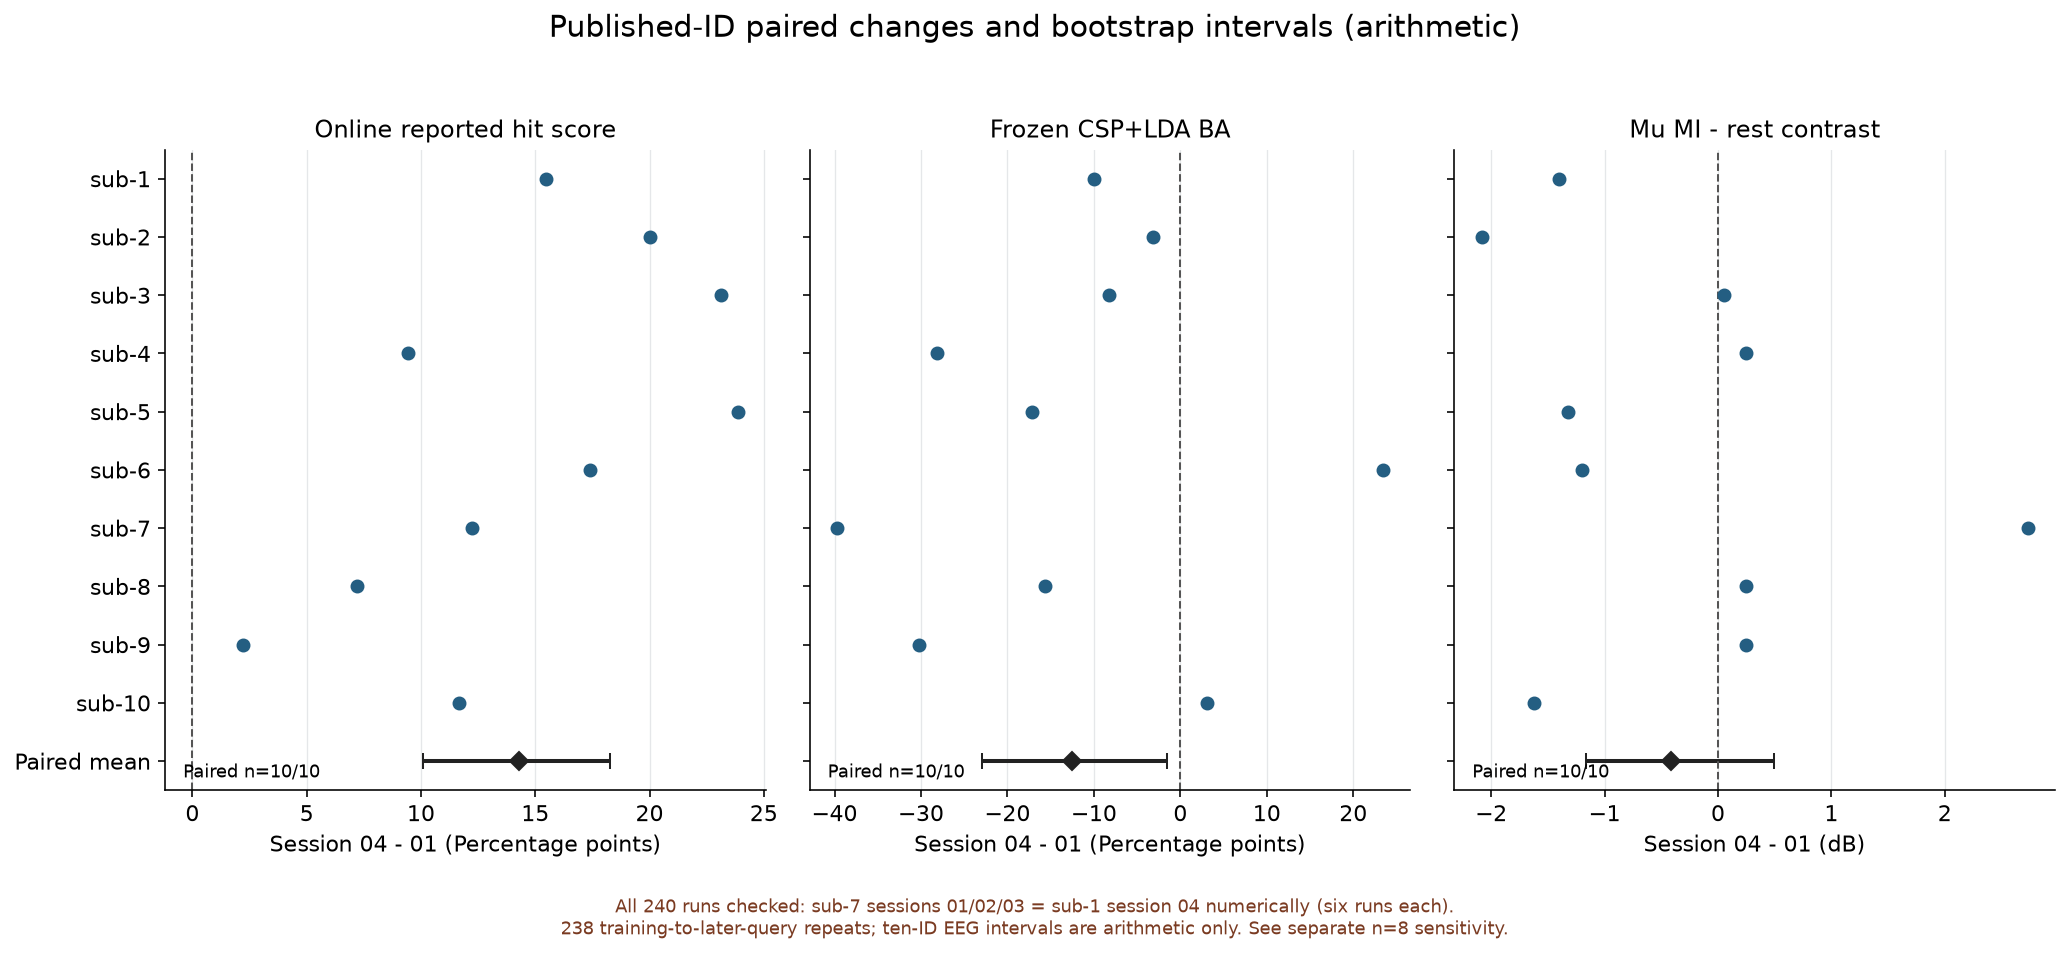

,metric,n_paired_subjects,mean_change,median_change,n_increased,n_decreased,n_unchanged,subject_bootstrap_CI95_low,subject_bootstrap_CI95_high
0,mean_run_hit_percent,10,14.268,13.853,10,0,0,10.085,18.291
1,CSP_BA_percent,10,-12.573,-12.846,2,8,0,-22.954,-1.596
2,mu_MI_minus_rest_dB,10,-0.410,-0.573,5,5,0,-1.168,0.492


In [7]:
contrasts = [("mean_run_hit_percent", "Online reported hit score", "Percentage points"),
             ("CSP_BA_percent", "Frozen CSP+LDA BA", "Percentage points"),
             ("mu_MI_minus_rest_dB", "Mu MI - rest contrast", "dB")]
fig, axes = plt.subplots(1, 3, figsize=(14.4, 6.1), sharey=True)
for ax, (metric, title, unit) in zip(axes, contrasts):
    rows = individual_changes.loc[individual_changes.metric == metric].set_index("subject").reindex(SUBJECTS)
    values = pd.to_numeric(rows.last_minus_first, errors="coerce").to_numpy()
    ax.scatter(values, np.arange(10), color=BLUE, s=35, zorder=3)
    for i in np.flatnonzero(~np.isfinite(values)):
        ax.text(.98, i, "unavailable", ha="right", va="center",
                transform=ax.get_yaxis_transform(), fontsize=9)
    row = paired.loc[paired.metric == metric].iloc[0]
    if pd.notna(row.mean_change):
        ax.errorbar(row.mean_change, 10, xerr=[
            [row.mean_change - row.subject_bootstrap_CI95_low],
            [row.subject_bootstrap_CI95_high - row.mean_change]],
            fmt="D", color="#222222", capsize=4, ms=6, lw=2)
    ax.axvline(0, color="#555555", ls="--", lw=1)
    ax.set_title(title)
    ax.set_xlabel("Session 04 - 01 (" + unit + ")")
    ax.set_yticks(range(11), SUBJECTS + ["Paired mean"])
    ax.grid(axis="x", color="#e5e7e9", lw=.65)
    ax.text(.03, .02, f"Paired n={int(row.n_paired_subjects)}/10", transform=ax.transAxes, fontsize=9)
axes[0].invert_yaxis()
fig.suptitle("Published-ID paired changes and bootstrap intervals (arithmetic)", fontsize=15)
fig.tight_layout(rect=[0, 0, 1, .95])
show_figure(fig)
display(paired.loc[paired.metric.isin([row[0] for row in contrasts]),
    ["metric", "n_paired_subjects", "mean_change", "median_change", "n_increased",
     "n_decreased", "n_unchanged", "subject_bootstrap_CI95_low", "subject_bootstrap_CI95_high"]].round(3))

### 3. Mu/Beta 任务对比与绝对 Mu 功率

任务对比与绝对功率回答不同问题。绝对功率为每类、每 run 的算术功率均值，
再对 runs 和参与者等权；不把较负的 MI−rest 对比预先定义为学习。
10 人变化分布可以与先导结果不同。

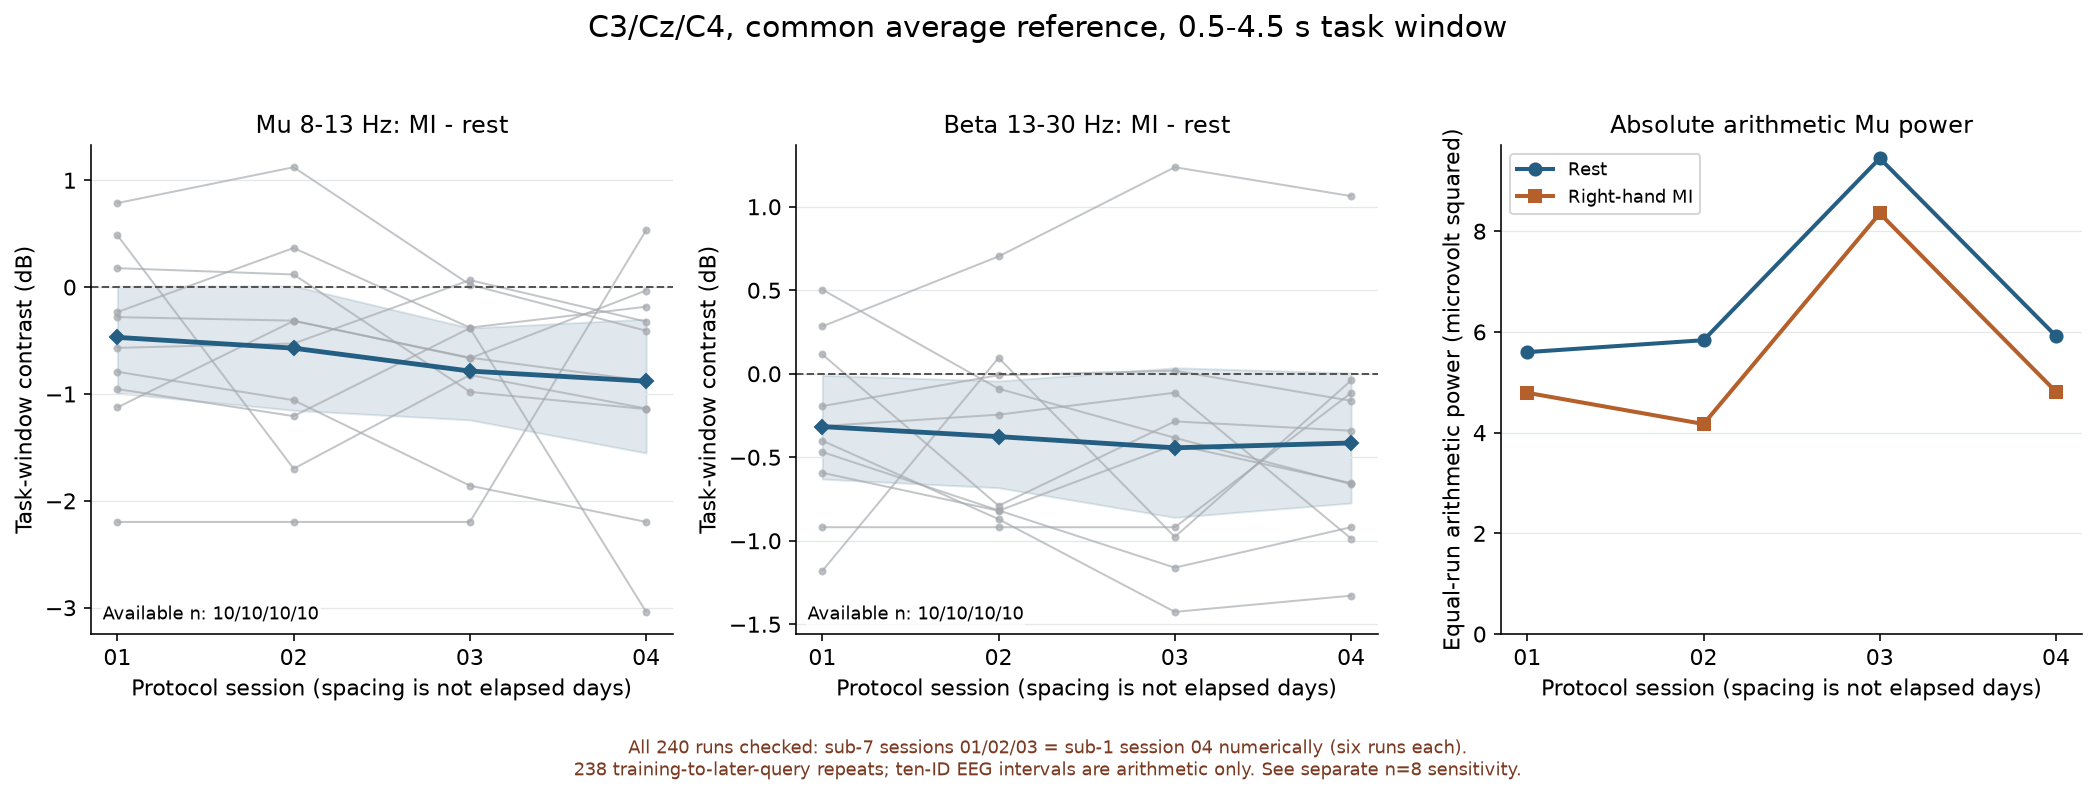

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14.6, 5.0))
for ax, metric, title in [
    (axes[0], "mu_MI_minus_rest_dB", "Mu 8-13 Hz: MI - rest"),
    (axes[1], "beta_MI_minus_rest_dB", "Beta 13-30 Hz: MI - rest")]:
    trajectories(ax, matrix(linked, metric), title, "Task-window contrast (dB)",
                 session_stats.loc[session_stats.metric == metric])
    ax.axhline(0, color="#555555", ls="--", lw=1)
for metric, label, color, marker in [
    ("mu_rest_power_uV2", "Rest", BLUE, "o"),
    ("mu_MI_power_uV2", "Right-hand MI", ORANGE, "s")]:
    means = session_stats.loc[session_stats.metric == metric].set_index("session").reindex(SESSIONS)["mean"]
    axes[2].plot(SESSION_X, means, marker=marker, color=color, lw=2, label=label)
axes[2].set_title("Absolute arithmetic Mu power")
axes[2].set_ylabel("Equal-run arithmetic power (microvolt squared)")
axes[2].set_ylim(bottom=0)
decorate_session_axis(axes[2])
axes[2].legend(fontsize=9)
fig.suptitle("C3/Cz/C4, common average reference, 0.5-4.5 s task window", fontsize=15)
fig.tight_layout(rect=[0, 0, 1, .95])
show_figure(fig)

### 4. QC 负荷、共同 runs 与 reference 敏感性

主分析保留全部符合固定 5 秒输入条件的真实 trial。下方三种谱摘要分别使用六个 runs 的全部合格 trial、
共同 run03–06 的全部 trial，以及共同 run03–06 中 QC 未标记 trial；
最后两者有相同 run 集，可以看筛选敏感性。reference 另分面展示。
未满足完整类/run 单元的参与者保持缺失，每点注明可用 n；该图不伪装为新的主对比。

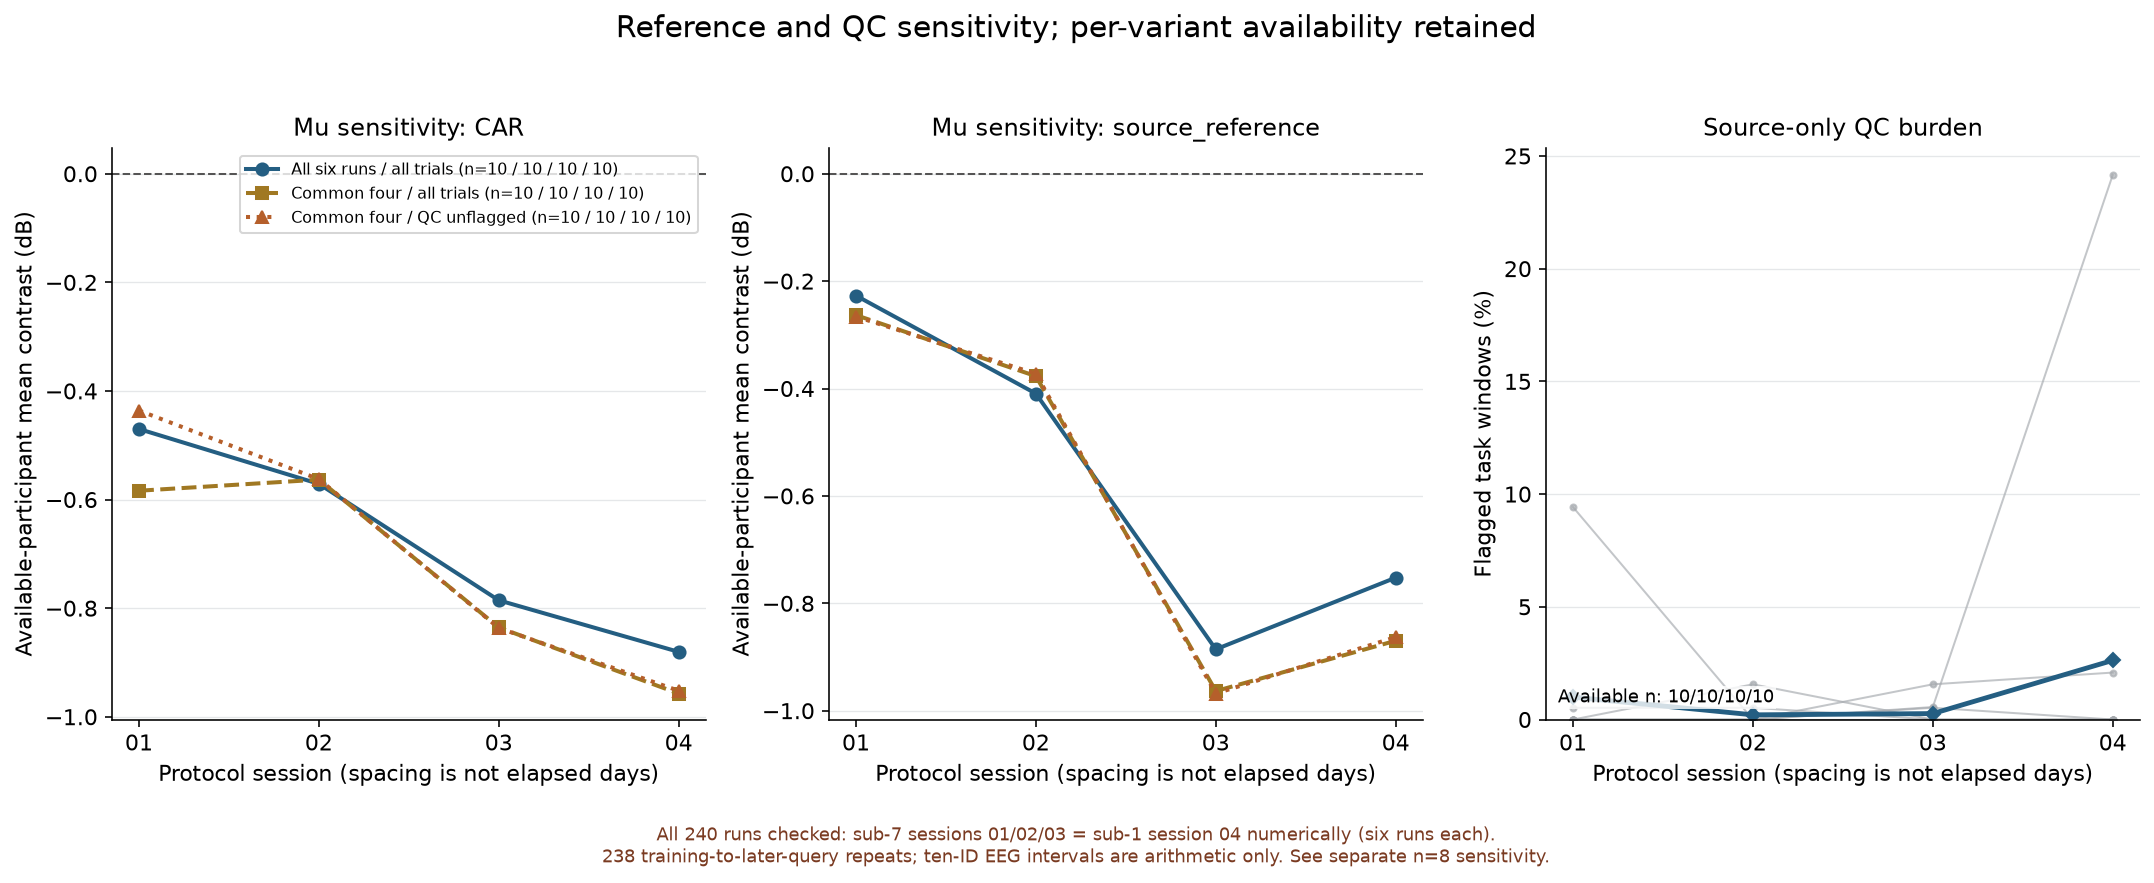

In [9]:
variants = [("all_six_runs_all_trials", "All six runs / all trials", BLUE, "o", "-"),
            ("common_four_runs_all_trials", "Common four / all trials", GOLD, "s", "--"),
            ("common_four_runs_qc_unflagged", "Common four / QC unflagged", ORANGE, "^", ":")]
fig, axes = plt.subplots(1, 3, figsize=(15, 5.6))
for ax, reference in zip(axes[:2], ["CAR", "source_reference"]):
    for variant, label, color, marker, style in variants:
        rows = spectral.loc[(spectral.reference == reference) & (spectral.variant == variant) &
                            (spectral.band == "mu")]
        values = matrix(rows, "MI_minus_rest_log_power_dB")
        counts = np.isfinite(values).sum(axis=0)
        means = np.divide(np.nansum(values, axis=0), counts,
                          out=np.full(4, np.nan), where=counts > 0)
        count_label = " / ".join(map(str, counts))
        ax.plot(SESSION_X, means, color=color, marker=marker, ls=style, lw=2,
                label=label + " (n=" + count_label + ")")
    ax.axhline(0, color="#555555", ls="--", lw=1)
    ax.set_title("Mu sensitivity: " + reference)
    ax.set_ylabel("Available-participant mean contrast (dB)")
    decorate_session_axis(ax)
qc_fraction = linked.assign(qc_percent=100 * linked.n_qc_flagged / linked.n_EEG_trials)
trajectories(axes[2], matrix(qc_fraction, "qc_percent"), "Source-only QC burden", "Flagged task windows (%)")
axes[2].set_ylim(bottom=0)
axes[0].legend(loc="best", fontsize=8)
fig.suptitle("Reference and QC sensitivity; per-variant availability retained", fontsize=15)
fig.tight_layout(rect=[0, 0, 1, .95])
show_figure(fig)

### 5. 匹配几何、会话内距离与不可用性

下面分别展示相对 session01 的 AIRM、会话内 run AIRM 均值和 PCA 子空间距离。
六-run 和 QC 共同四-run 是不同敏感性估计；每人 10 次固定样本抽样先平均，
灰线仍代表一个参与者。重复 seeds 不是额外参与者。
会话间和会话内距离是异质性描述，不能替代 split-half 可靠性、测量误差验证，
或直接相减解释成学习效应。重复副本的近零距离不能作为生物学稳定证据。

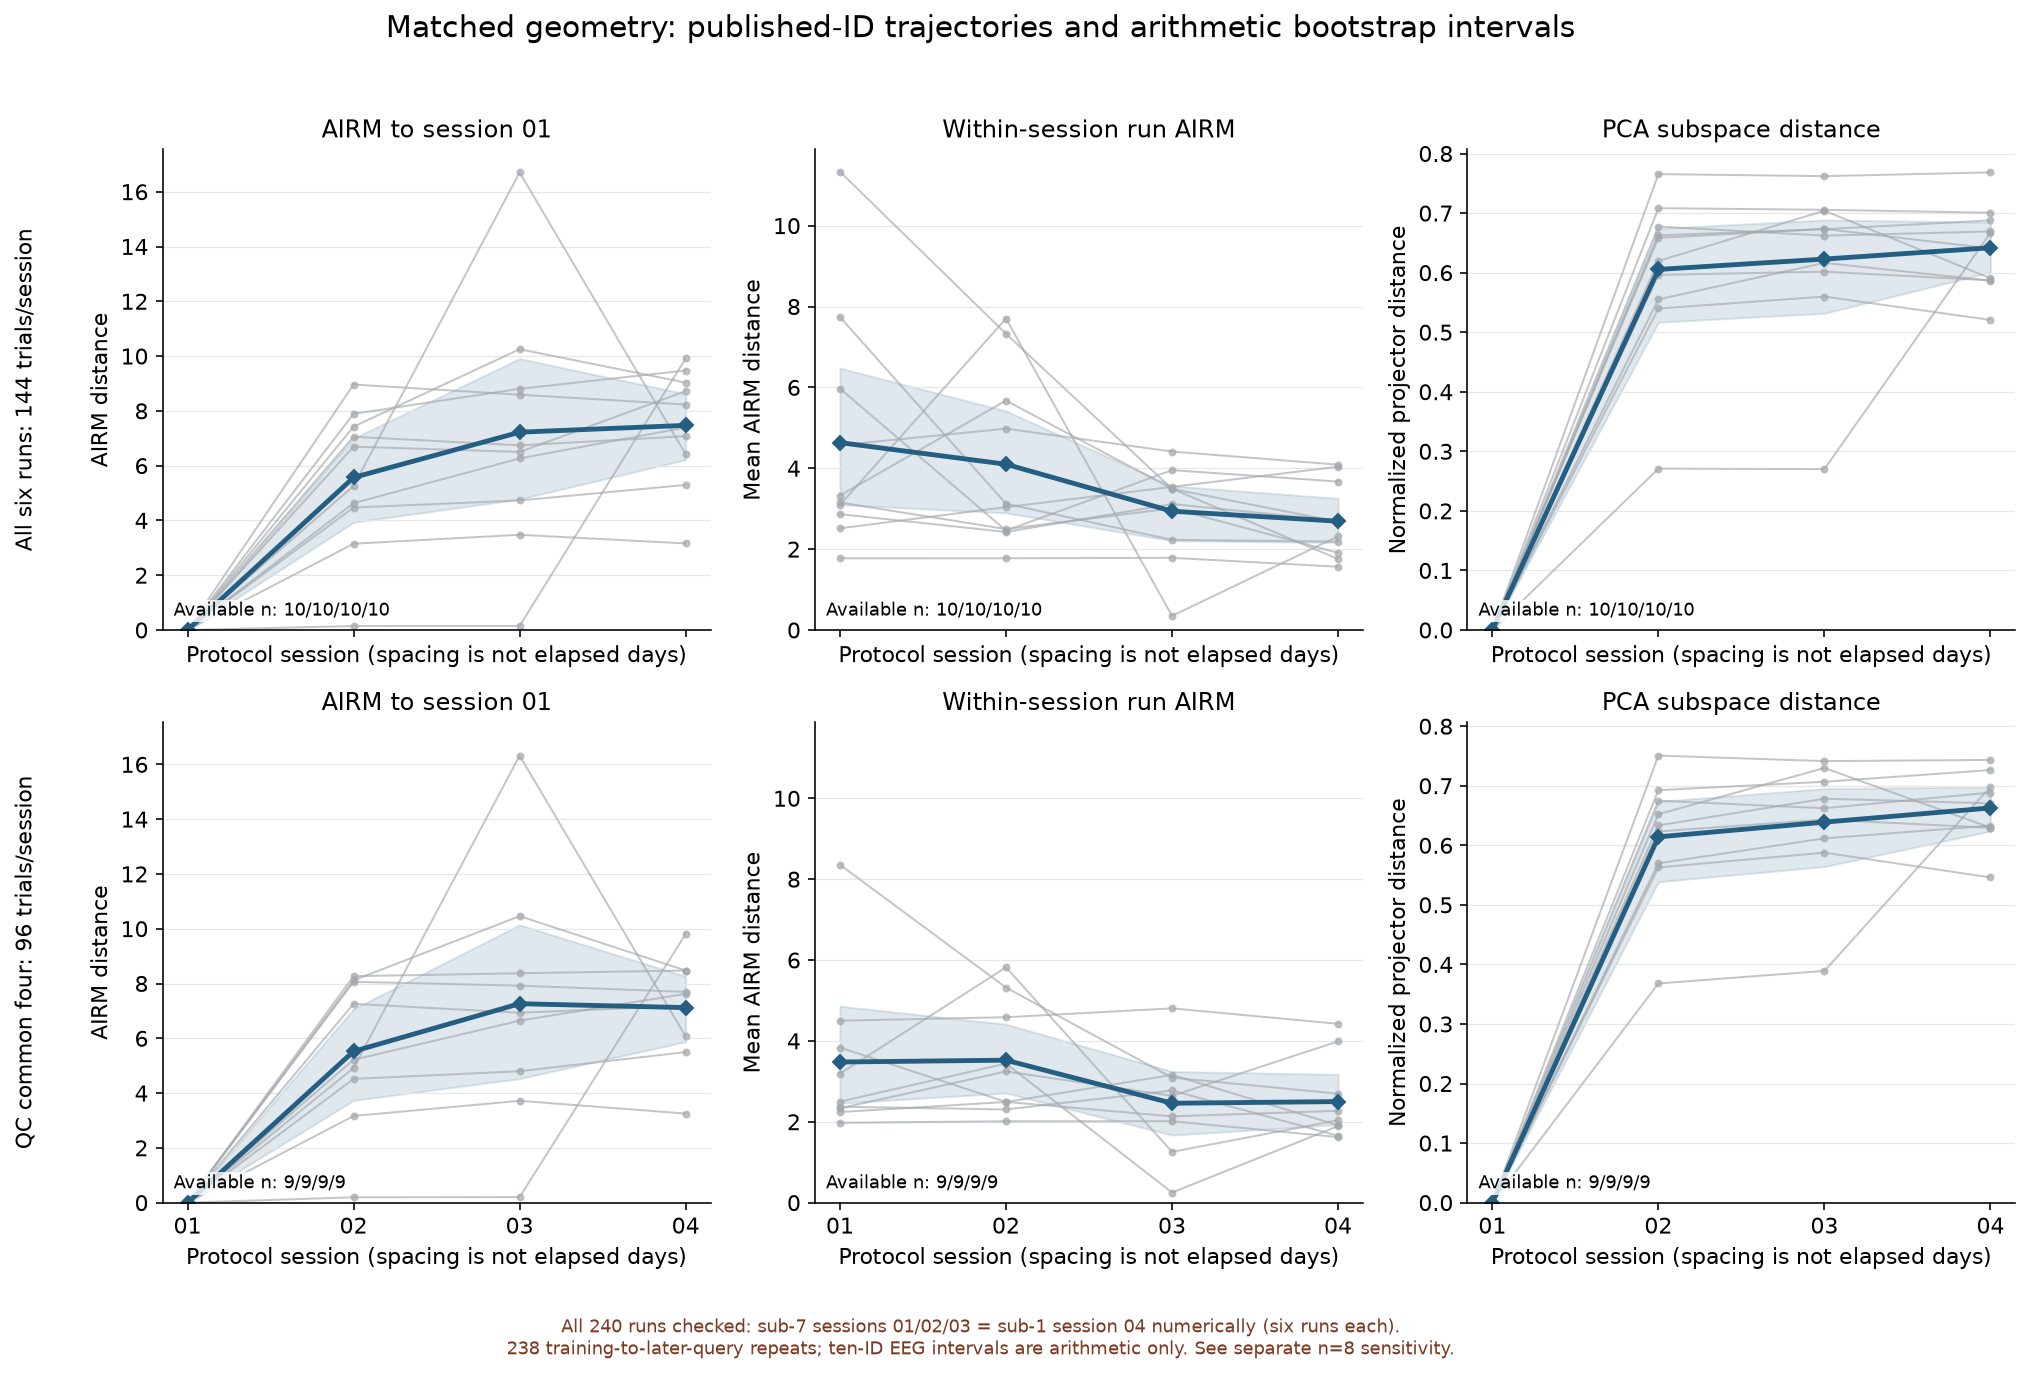

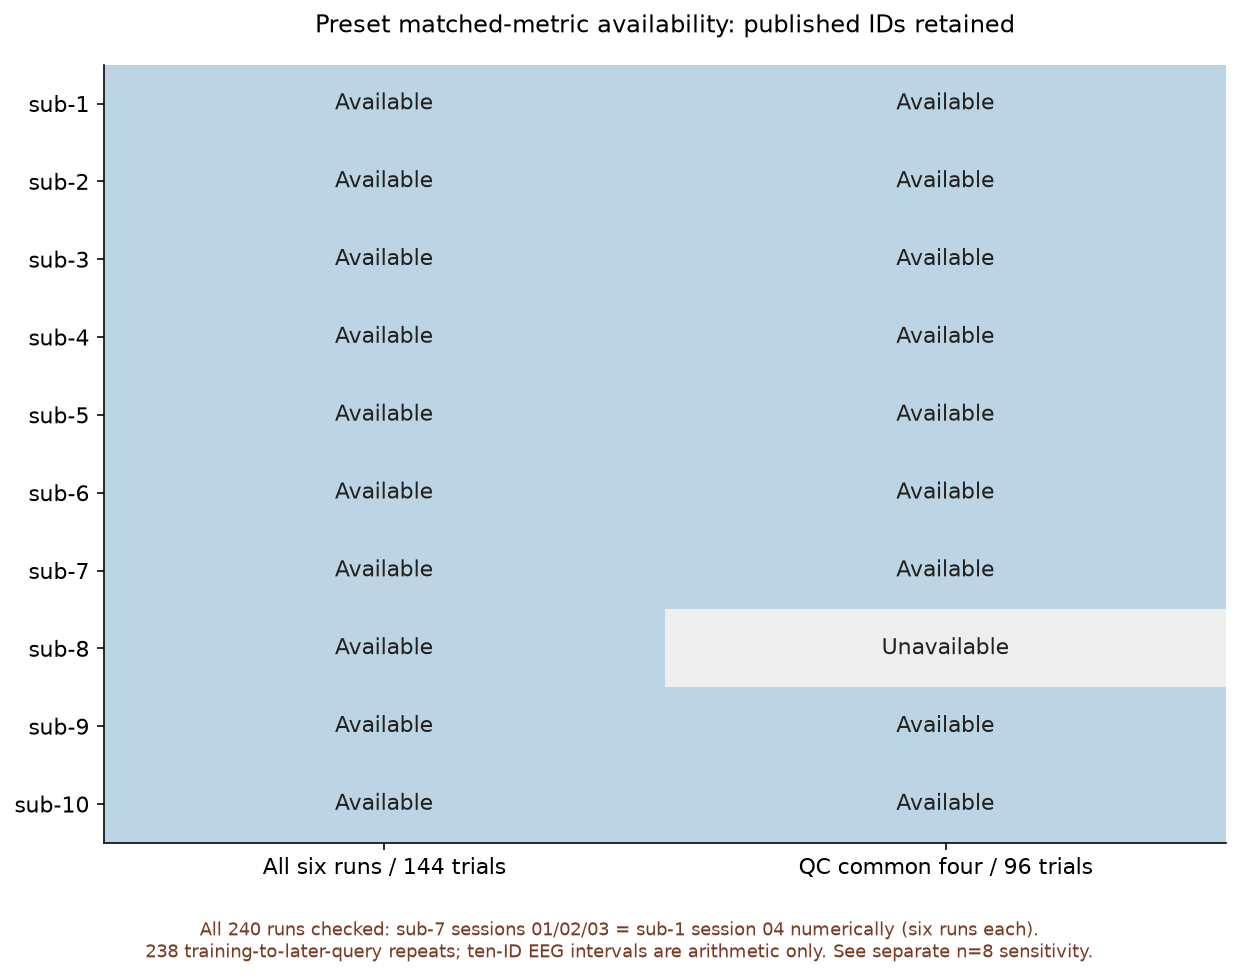

,subject,variant,status,error
60,sub-8,qc_common_four_runs,unavailable,"Insufficient preset matched cells: [{""session""..."


In [10]:
geometry_fields = [("AIRM_to_session01", "AIRM to session 01", "AIRM distance"),
                   ("within_session_run_AIRM_mean", "Within-session run AIRM", "Mean AIRM distance"),
                   ("PCA_subspace_distance", "PCA subspace distance", "Normalized projector distance")]
geometry_variants = [("all_six_runs", "All six runs: 144 trials/session"),
                     ("qc_common_four_runs", "QC common four: 96 trials/session")]
fig, axes = plt.subplots(2, 3, figsize=(14.6, 9.0), sharex=True)
for row_number, (variant, variant_label) in enumerate(geometry_variants):
    rows = geometry.loc[geometry.variant == variant]
    for ax, (field, title, unit) in zip(axes[row_number], geometry_fields):
        stats = matched_stats.loc[(matched_stats.variant == variant) & (matched_stats.metric == field)]
        trajectories(ax, matrix(rows, field), title, unit, stats)
        ax.set_ylim(bottom=0)
    axes[row_number, 0].text(-.25, .5, variant_label, rotation=90,
                            transform=axes[row_number, 0].transAxes, ha="center", va="center", fontsize=11)
for col in range(3):
    ymax = max(axes[0, col].get_ylim()[1], axes[1, col].get_ylim()[1])
    for ax in axes[:, col]:
        ax.set_ylim(0, ymax)
fig.suptitle("Matched geometry: published-ID trajectories and arithmetic bootstrap intervals", fontsize=15)
fig.tight_layout(rect=[.04, 0, 1, .96])
show_figure(fig)

availability = geometry.loc[geometry.session == SESSIONS[0], ["subject", "variant", "status", "error"]]
availability_matrix = availability.assign(available=availability.status == "available").pivot(
    index="subject", columns="variant", values="available").reindex(index=SUBJECTS,
    columns=[v[0] for v in geometry_variants]).to_numpy(dtype=bool)
fig, ax = plt.subplots(figsize=(8.7, 6.3))
ax.imshow(availability_matrix.astype(int), cmap=ListedColormap(["#eeeeee", "#bcd4e3"]),
          vmin=0, vmax=1, aspect="auto")
for i in range(10):
    for j in range(2):
        ax.text(j, i, "Available" if availability_matrix[i, j] else "Unavailable",
                ha="center", va="center", color="#222222", fontsize=11)
ax.set_yticks(range(10), SUBJECTS)
ax.set_xticks([0, 1], ["All six runs / 144 trials", "QC common four / 96 trials"])
ax.set_title("Preset matched-metric availability: published IDs retained", pad=16)
fig.tight_layout()
show_figure(fig)
unavailable = availability.loc[availability.status != "available"]
display(unavailable if len(unavailable) else Markdown("所有预设匹配指标均可用。"))

### 6. 首末神经变化与行为变化的参与者级关系

每个点是一个发布身份，保留 ID 与配对可用数；不是 40 个会话或几千个 trial
的独立相关。该图只探索同一人的变化关系，不能调整未记录的在线重校准、
疲劳和硬件混杂。没有验证过的 trial 成功标签；此处也不生成标签。
下表列出五组 Pearson/Spearman 估计及完整参与者配对 bootstrap 区间；
多重比较未调整。它们是协议后保存估计方案的探索性关联，不是 H2 确证检验。
完整数值检查已确认来源重复，因此下图原十身份 EEG 关联不能作为独立样本证据。
八身份敏感性另外保留全五组估计，不只选择区间不跨零者。

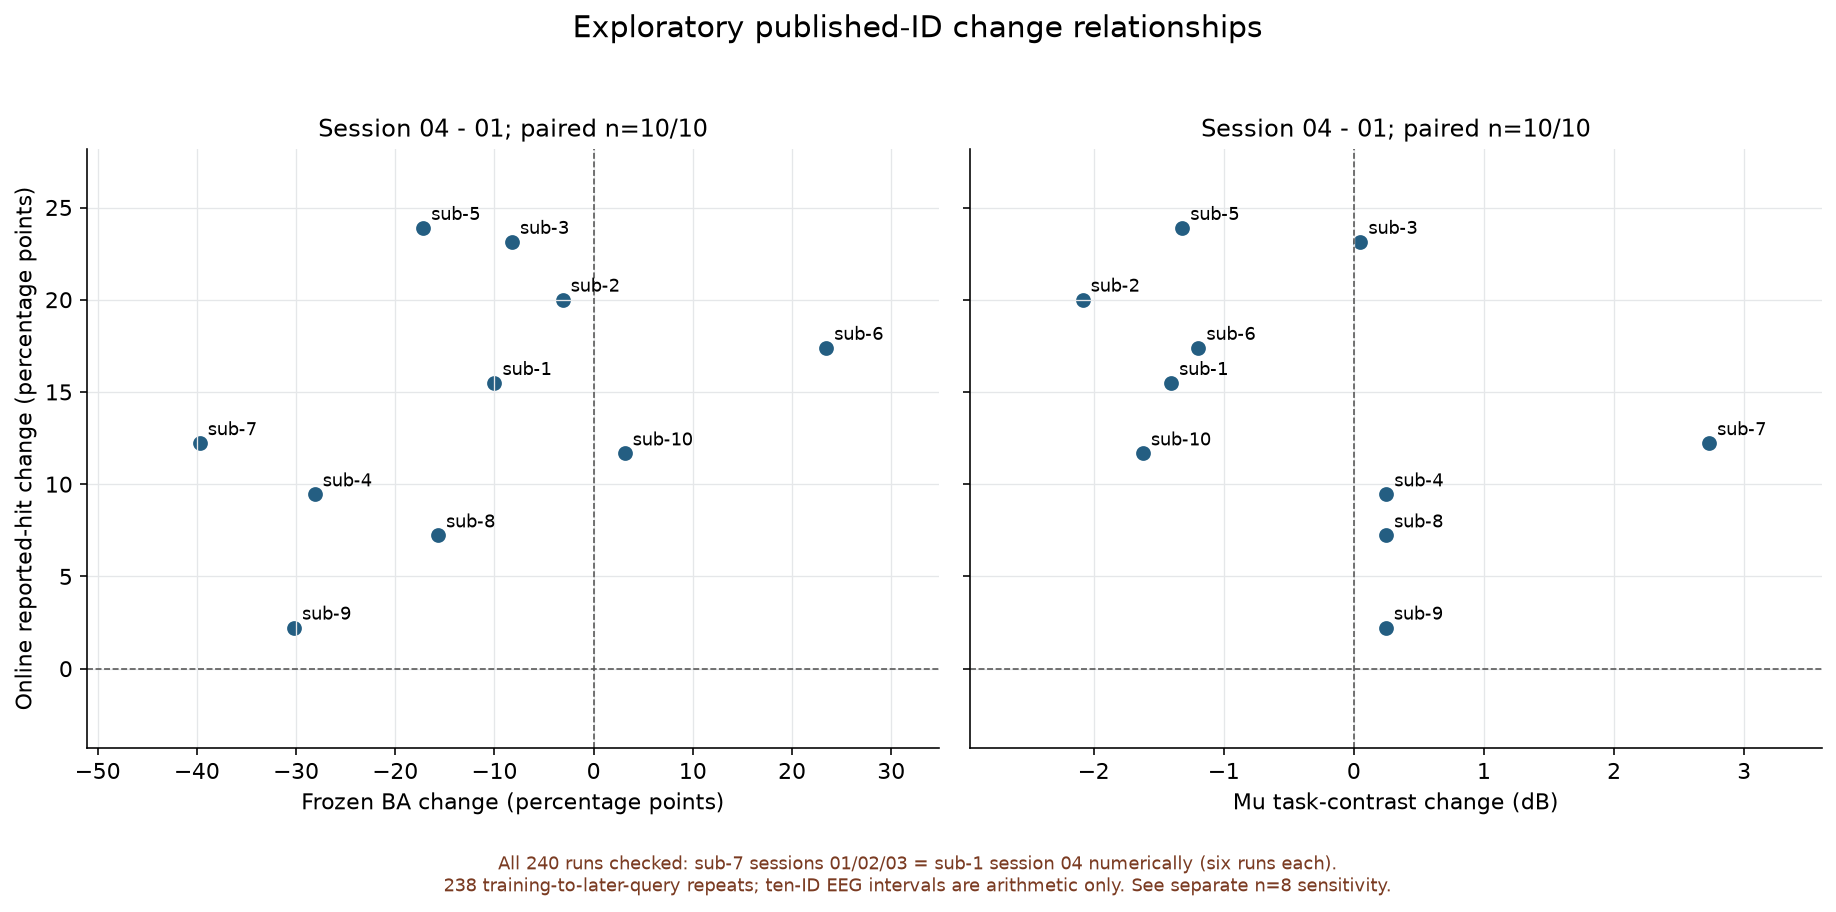

,association,estimator,n_complete_paired_participants,estimate,participant_bootstrap_CI95_low,participant_bootstrap_CI95_high
0,BA_change_vs_behavior_change,Pearson_r,10,0.424,-0.050,0.777
1,BA_change_vs_behavior_change,Spearman_rho,10,0.394,-0.333,0.852
2,Mu_change_vs_behavior_change,Pearson_r,10,-0.412,-0.876,-0.014
3,Mu_change_vs_behavior_change,Spearman_rho,10,-0.479,-0.764,0.176
4,Mu_change_vs_BA_change,Pearson_r,10,-0.727,-0.933,-0.355
5,Mu_change_vs_BA_change,Spearman_rho,10,-0.721,-0.962,-0.152
6,all_six_runs_AIRM_session04_vs_BA_change,Pearson_r,10,-0.624,-0.931,0.331
7,all_six_runs_AIRM_session04_vs_BA_change,Spearman_rho,10,-0.503,-0.925,0.291
8,all_six_runs_PCA_session04_vs_BA_change,Pearson_r,10,0.020,-0.651,0.666
9,all_six_runs_PCA_session04_vs_BA_change,Spearman_rho,10,0.164,-0.686,0.796


### 来源审计后的八身份敏感性（另存，未重新拟合）

同时排除 sub-1/sub-7 的依据是跨身份数值副本；观察后的选择不是独立确认。没有发现剩余八身份精确副本不等于验证生物学可靠性。原始 19 人行为样本量不变。

,metric,n_paired_subjects,mean_change,n_increased,n_decreased,subject_bootstrap_CI95_low,subject_bootstrap_CI95_high
0,mean_run_hit_percent,8,14.371,8,0,9.189,19.325
1,CSP_BA_percent,8,-9.502,2,6,-20.244,2.735
2,mu_MI_minus_rest_dB,8,-0.679,4,4,-1.317,-0.047
3,beta_MI_minus_rest_dB,8,-0.167,3,5,-0.654,0.381
4,mu_rest_power_uV2,8,-1.140,4,4,-3.808,1.327
5,mu_MI_power_uV2,8,-1.730,2,6,-3.622,-0.368
6,beta_rest_power_uV2,8,-3.283,3,5,-6.914,-0.324
7,beta_MI_power_uV2,8,-3.153,1,7,-6.507,-0.567


,association,estimator,n_complete_paired_participants,estimate,participant_bootstrap_CI95_low,participant_bootstrap_CI95_high
0,BA_change_vs_behavior_change,Pearson_r,8,0.438,-0.299,0.888
1,BA_change_vs_behavior_change,Spearman_rho,8,0.381,-0.630,0.923
2,Mu_change_vs_behavior_change,Pearson_r,8,-0.538,-0.935,0.213
3,Mu_change_vs_behavior_change,Spearman_rho,8,-0.595,-0.905,0.151
4,Mu_change_vs_BA_change,Pearson_r,8,-0.619,-0.941,-0.203
5,Mu_change_vs_BA_change,Spearman_rho,8,-0.619,-0.973,0.140
6,all_six_runs_AIRM_session04_vs_BA_change,Pearson_r,8,-0.546,-0.948,0.571
7,all_six_runs_AIRM_session04_vs_BA_change,Spearman_rho,8,-0.381,-0.926,0.589
8,all_six_runs_PCA_session04_vs_BA_change,Pearson_r,8,0.103,-0.759,0.829
9,all_six_runs_PCA_session04_vs_BA_change,Spearman_rho,8,0.357,-0.842,0.969


In [11]:
changes_wide = individual_changes.pivot(index="subject", columns="metric", values="last_minus_first").reindex(SUBJECTS)
fig, axes = plt.subplots(1, 2, figsize=(12.8, 5.8), sharey=True)
for ax, field, label in [(axes[0], "CSP_BA_percent", "Frozen BA change (percentage points)"),
                         (axes[1], "mu_MI_minus_rest_dB", "Mu task-contrast change (dB)")]:
    x = pd.to_numeric(changes_wide[field], errors="coerce").to_numpy()
    y = pd.to_numeric(changes_wide.mean_run_hit_percent, errors="coerce").to_numpy()
    valid = np.isfinite(x) & np.isfinite(y)
    ax.scatter(x[valid], y[valid], color=BLUE, s=40)
    for subject, xx, yy in zip(np.asarray(SUBJECTS)[valid], x[valid], y[valid]):
        ax.annotate(subject, (xx, yy), xytext=(4, 4), textcoords="offset points", fontsize=9)
    ax.axhline(0, color="#555555", ls="--", lw=.8)
    ax.axvline(0, color="#555555", ls="--", lw=.8)
    ax.set_xlabel(label)
    ax.set_title(f"Session 04 - 01; paired n={valid.sum()}/10")
    ax.grid(color="#e5e7e9", lw=.65)
    ax.margins(x=.18, y=.18)
axes[0].set_ylabel("Online reported-hit change (percentage points)")
fig.suptitle("Exploratory published-ID change relationships", fontsize=15)
fig.tight_layout(rect=[0, 0, 1, .95])
show_figure(fig)

ASSOCIATIONS = RESULTS.parent / "associations_run01"
association_receipt = json.loads((ASSOCIATIONS / "association_receipt.json").read_text())
assert association_receipt["synthetic"] is False
assert association_receipt["status"] == "actual_participant_associations_completed"
assert association_receipt["bootstrap_unit"] == "paired whole participant"
assert association_receipt["input_sha256"]["summary_receipt"]["sha256"] == sha256(RESULTS / "summary_receipt.json")
for name, expected_hash in association_receipt["output_sha256"].items():
    assert sha256(ASSOCIATIONS / name) == expected_hash, name
    source_rows.append({"Artifact": "associations_run01/" + name, "SHA-256": expected_hash})
association_table = pd.read_csv(ASSOCIATIONS / "association_estimates.tsv", sep="\t")
assert len(association_table) == 10
assert (association_table.n_requested_participants == 10).all()
assert (association_table.n_complete_paired_participants == 10).all()
display(association_table[["association", "estimator", "n_complete_paired_participants", "estimate",
                           "participant_bootstrap_CI95_low", "participant_bootstrap_CI95_high"]].round(3))
display(Markdown("### 来源审计后的八身份敏感性（另存，未重新拟合）\n\n"
                 "同时排除 sub-1/sub-7 的依据是跨身份数值副本；观察后的选择不是独立确认。"
                 "没有发现剩余八身份精确副本不等于验证生物学可靠性。原始 19 人行为样本量不变。"))
display(sensitive_paired[["metric", "n_paired_subjects", "mean_change", "n_increased", "n_decreased",
                          "subject_bootstrap_CI95_low", "subject_bootstrap_CI95_high"]].round(3))
sensitive_associations = pd.read_csv(SENSITIVITY / "association_estimates.tsv", sep="\t")
assert len(sensitive_associations) == 10
assert (sensitive_associations.n_complete_paired_participants == 8).all()
display(sensitive_associations[["association", "estimator", "n_complete_paired_participants", "estimate",
                                "participant_bootstrap_CI95_low", "participant_bootstrap_CI95_high"]].round(3))

## Takeaways

结论随实际保存的队列表格更新；首末变化和个体异质性见上面的配对表。
失败的冻结读出、QC 负荷及不可用匹配单元均保留，不能只引用表现更好的参与者。
观察性行为改善、任务对比变化、几何漂移和早期映射可读性是不同证据。
当前公开行为首末改善为 +14.268 个百分点；冻结 BA 首末均值变化为
−12.573 个百分点；Mu 对比变化区间跨零，个体方向为增加/下降各 5 人。
后两项及神经关联包含已确认的来源副本，十身份区间仅为算术记录。
八身份来源敏感性 BA 变化 −9.502 pp、区间跨零；Mu 变化 −0.679 dB、区间不跨零，
但方向四增四降。区间位置随来源排除变化不构成学习或策略机制确认。

这些结果可以决定下一步的测量可靠性验证和充分 source-only baseline；
尚未实现/验证新的 Learning-Preserving 策略，也没有独立、无辅助延迟 retention
对照。H3/H4 的因果问题仍需前瞻性在线实验。

### 来源、执行环境与重运行

这个 notebook 的便携输入是 summary 目录中的七个小表、summary JSON、
summary_receipt JSON、两个配置文件和 associations_run01 的三个小表/JSON 及收据，
以及完整 numeric_signal_identity.json、independence_sensitivity_run01 的小表/JSON/收据；
不需要原始 EEG 张量来重画这些图。
receipt 保留更上游的审计、行为原字节和分析输出来源散列。下方验证的是
保存的绘图输入，不声称在本 notebook 中重复了完整原始 EEG 审计。

从仓库根目录运行（现有环境中注册 `bci-netbci-local` kernel）：

```bash
/workspace/.venvs/few-shot-mi-eeg/bin/python scripts/build_netbci_cohort_notebook.py --execute --overwrite
```

脚本用 nbformat 生成 notebook、nbclient 从头执行，nbconvert 导出 HTML。
阅读时无需运行 kernel。全页浏览器截图未验证；原生图像另行逐张检查。

In [12]:
display(pd.DataFrame(source_rows))
print(json.dumps({"summary_directory": str(RESULTS.relative_to(ROOT)),
                  "config_sha256": sha256(CONFIG),
                  "summary_receipt_sha256": sha256(RESULTS / "summary_receipt.json"),
                  "summary_source_provenance": {key: receipt["provenance"][key]
                      for key in ["seed", "git_commit", "git_dirty", "python", "versions"]},
                  "notebook_runtime": {"python": platform.python_version(), "numpy": np.__version__,
                                       "pandas": pd.__version__, "matplotlib": plt.matplotlib.__version__,
                                       **{name: importlib.metadata.version(name) for name in
                                          ["nbformat", "nbclient", "nbconvert", "ipykernel"]}},
                  "scope": "Saved verified tables only; native editable figures; no raw EEG/model fits"},
                 indent=2, ensure_ascii=False))

,Artifact,SHA-256
0,participant_session_join.tsv,0b26f8e914390797ffadc4eee0a92cfc511ccedeeef75f...
1,cohort_session_statistics.tsv,457865c2824983b5ba89d55634569b2a790dbd0383af6d...
2,participant_first_last_changes.tsv,04e4f633ee1dafc8298a5c731ffbc6c9964591aec1a2e1...
3,cohort_paired_changes.tsv,36c2721017413c493b02a1f9af5db923db5f15ea77f34e...
4,spectral_reference_QC_sensitivity.tsv,a168416f414f22720d34ad5b050cb26599d6b7e29eaab5...
5,participant_matched_geometry.tsv,36b8e824cf162b509176f0f5c5ca354c62393455460cd6...
6,cohort_matched_statistics.tsv,a52c24af7a3d3a57a262ba29e19716e470659136783d65...
7,cohort_summary.json,eedd61104299b342b19b6f4e0080fc1fbd6bdf221dd8e8...
8,independence_sensitivity_run01/cohort_paired_c...,2e6e351c146662f9781b637f034713932a4944710ed449...
9,independence_sensitivity_run01/cohort_session_...,0985852104997465d694cc098f4f309ad54e2197d8f306...


{
  "summary_directory": "research_logs/netbci_cohort_resume_20261010/summary_run01",
  "config_sha256": "2bead8bccd0396e0358bb8167324621e80d48087ba011a334224f73962d10904",
  "summary_receipt_sha256": "1f054d052bd9158b37278842920a747fe44ea8268a35b7e4759f13f6ff7417f1",
  "summary_source_provenance": {
    "seed": 42,
    "git_commit": "ed81d67cbe8bf3dec486095959e24b014e2f00ca",
    "git_dirty": true,
    "python": "3.11.16",
    "versions": {
      "numpy": "2.2.6",
      "scipy": "1.15.3",
      "scikit-learn": "1.7.2",
      "mne": "1.10.2",
      "torch": "2.8.0+cpu",
      "torchaudio": "2.8.0+cpu",
      "braindecode": "1.2.0",
      "moabb": "1.4.3"
    }
  },
  "notebook_runtime": {
    "python": "3.11.16",
    "numpy": "2.2.6",
    "pandas": "3.0.6",
    "matplotlib": "3.11.2",
    "nbformat": "5.10.4",
    "nbclient": "0.10.2",
    "nbconvert": "7.16.6",
    "ipykernel": "6.30.1"
  },
  "scope": "Saved verified tables only; native editable figures; no raw EEG/model fits"
}
